In [1]:
# =========================================
# CELL 1: Install required packages
# =========================================
!pip install -q noisereduce audiomentations soundfile

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 86.1/86.1 kB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 109.4/109.4 kB 10.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 248.5/248.5 kB 14.4 MB/s eta 0:00:00


In [2]:
# =========================================
# CELL 2: Imports
# =========================================
import os
import glob
import random
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import librosa
import soundfile as sf
import noisereduce as nr

import matplotlib.pyplot as plt
import seaborn as sns

from tqdm import tqdm
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader

from audiomentations import Compose, AddGaussianNoise, PitchShift

In [3]:
# =========================================
# CELL 3: Reproducibility + Constants
# =========================================
SEED = 36

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)
    torch.cuda.manual_seed_all(SEED)

SR = 16000
TOP_DB = 20
TARGET_RMS = 0.1
EPS = 1e-8

SEGMENT_SECONDS = 1.0
SEGMENT_SAMPLES = int(SR * SEGMENT_SECONDS)

N_MELS = 64
FRAMES = 96
N_FFT = 400
HOP_LENGTH = 160
FMIN = 125
FMAX = 7500

BATCH_SIZE = 16
EPOCHS = 20
LEARNING_RATE = 1e-4
NUM_WORKERS = 0

In [4]:
# =========================================
# CELL 4: Paths
# =========================================
DATASET_ROOT = "/kaggle/input/datasets/murtadhanajim/gender-recognition-by-voiceoriginal/data"

MALE_DIR = os.path.join(DATASET_ROOT, "male")
FEMALE_DIR = os.path.join(DATASET_ROOT, "female")

WORK_DIR = "/kaggle/working"
PROCESSED_DIR = os.path.join(WORK_DIR, "processed_data")
MODEL_PATH = os.path.join(WORK_DIR, "best_gender_model.pth")
PLOTS_DIR = os.path.join(WORK_DIR, "plots")

os.makedirs(PROCESSED_DIR, exist_ok=True)
os.makedirs(PLOTS_DIR, exist_ok=True)

In [5]:
# =========================================
# CELL 5: Load and Balance Dataset
# =========================================
male_files = sorted(glob.glob(os.path.join(MALE_DIR, "*.wav")))
female_files = sorted(glob.glob(os.path.join(FEMALE_DIR, "*.wav")))

print("Original male files   :", len(male_files))
print("Original female files :", len(female_files))

SAMPLE_NUMS = 5768
male_files = random.sample(male_files, SAMPLE_NUMS)

rows = []

for path in male_files:
    rows.append([path, 0, "male"])

for path in female_files:
    rows.append([path, 1, "female"])

metadata = pd.DataFrame(rows, columns=["path", "label", "label_name"])

print()
print(metadata["label_name"].value_counts())
metadata.head()

Original male files   : 10380
Original female files : 5768

label_name
male      5768
female    5768
Name: count, dtype: int64


,path,label,label_name
0,/kaggle/input/datasets/murtadhanajim/gender-re...,0,male
1,/kaggle/input/datasets/murtadhanajim/gender-re...,0,male
2,/kaggle/input/datasets/murtadhanajim/gender-re...,0,male
3,/kaggle/input/datasets/murtadhanajim/gender-re...,0,male
4,/kaggle/input/datasets/murtadhanajim/gender-re...,0,male


In [6]:
# =========================================
# CELL 6: Train / Validation / Test Split
# =========================================
train_df, temp_df = train_test_split(
    metadata,
    test_size=0.30,
    stratify=metadata["label"],
    random_state=SEED
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    stratify=temp_df["label"],
    random_state=SEED
)

print("Train      :", len(train_df))
print("Validation :", len(val_df))
print("Test       :", len(test_df))

Train      : 8075
Validation : 1730
Test       : 1731


In [7]:
# =========================================
# CELL 7: Preprocessing Functions
# =========================================
def rms_normalize(signal, target_rms=0.1):
    rms = np.sqrt(np.mean(signal ** 2) + EPS)
    return signal * (target_rms / rms)

def preprocess_audio(file_path):
    signal, _ = librosa.load(file_path, sr=SR)

    signal = nr.reduce_noise(y=signal, sr=SR)
    signal, _ = librosa.effects.trim(signal, top_db=TOP_DB)

    if len(signal) == 0:
        signal, _ = librosa.load(file_path, sr=SR)

    signal = rms_normalize(signal, TARGET_RMS)
    signal = signal / (np.max(np.abs(signal)) + EPS)

    return signal.astype(np.float32)

In [8]:
# =========================================
# CELL 8: Augmentation
# =========================================
augmenter = Compose([
    AddGaussianNoise(
        min_amplitude=0.001,
        max_amplitude=0.01,
        p=0.8
    ),
    PitchShift(
        min_semitones=-2,
        max_semitones=2,
        p=0.8
    )
])

In [9]:
# =========================================
# CELL 9: Preprocess and Save Audio
# =========================================
for split_name, split_df in [
    ("train", train_df),
    ("val", val_df),
    ("test", test_df)
]:
    print(f"\nProcessing {split_name} set...")

    for _, row in tqdm(split_df.iterrows(), total=len(split_df)):
        original_path = row["path"]
        label_name = row["label_name"]

        file_name = os.path.splitext(os.path.basename(original_path))[0]

        save_dir = os.path.join(PROCESSED_DIR, split_name, label_name)
        os.makedirs(save_dir, exist_ok=True)

        cleaned_audio = preprocess_audio(original_path)

        clean_path = os.path.join(save_dir, f"{file_name}.wav")
        sf.write(clean_path, cleaned_audio, SR)

        if split_name == "train":
            for i in range(3):
                augmented_audio = augmenter(
                    samples=cleaned_audio,
                    sample_rate=SR
                )

                augmented_audio = augmented_audio / (np.max(np.abs(augmented_audio)) + EPS)

                aug_path = os.path.join(save_dir, f"{file_name}_aug{i+1}.wav")
                sf.write(aug_path, augmented_audio.astype(np.float32), SR)


Processing train set...


100%|██████████| 8075/8075 [15:08<00:00,  8.89it/s]



Processing val set...


100%|██████████| 1730/1730 [01:42<00:00, 16.91it/s]



Processing test set...


100%|██████████| 1731/1731 [01:41<00:00, 17.12it/s]


In [10]:
# =========================================
# CELL 10: Build Final DataFrames
# =========================================
def build_split_dataframe(split_name):
    rows = []

    for class_name, label in [("male", 0), ("female", 1)]:
        files = glob.glob(os.path.join(PROCESSED_DIR, split_name, class_name, "*.wav"))

        for file_path in files:
            rows.append([file_path, label])

    return pd.DataFrame(rows, columns=["path", "label"])

train_final = build_split_dataframe("train")
val_final = build_split_dataframe("val")
test_final = build_split_dataframe("test")

print("Train files      :", len(train_final))
print("Validation files :", len(val_final))
print("Test files       :", len(test_final))

Train files      : 32300
Validation files : 1730
Test files       : 1731


In [11]:
# =========================================
# CELL 11: Dataset Class
# =========================================
class GenderDataset(Dataset):
    def __init__(self, dataframe):
        self.dataframe = dataframe.reset_index(drop=True)

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
        file_path = self.dataframe.iloc[idx]["path"]
        label = self.dataframe.iloc[idx]["label"]

        signal, _ = librosa.load(file_path, sr=SR)

        if len(signal) < SEGMENT_SAMPLES:
            signal = np.pad(signal, (0, SEGMENT_SAMPLES - len(signal)))
        else:
            start = random.randint(0, len(signal) - SEGMENT_SAMPLES)
            signal = signal[start:start + SEGMENT_SAMPLES]

        signal = signal / (np.max(np.abs(signal)) + EPS)

        mel = librosa.feature.melspectrogram(
            y=signal,
            sr=SR,
            n_fft=N_FFT,
            hop_length=HOP_LENGTH,
            n_mels=N_MELS,
            fmin=FMIN,
            fmax=FMAX,
            power=2.0
        )

        logmel = librosa.power_to_db(mel, ref=np.max)

        if logmel.shape[1] < FRAMES:
            logmel = np.pad(logmel, ((0, 0), (0, FRAMES - logmel.shape[1])))
        else:
            logmel = logmel[:, :FRAMES]

        logmel = torch.tensor(logmel, dtype=torch.float32).unsqueeze(0)
        label = torch.tensor(label, dtype=torch.float32)

        return logmel, label

In [12]:
# =========================================
# CELL 12: DataLoaders
# =========================================
train_loader = DataLoader(
    GenderDataset(train_final),
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS
)

val_loader = DataLoader(
    GenderDataset(val_final),
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS
)

test_loader = DataLoader(
    GenderDataset(test_final),
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS
)

In [13]:
# =========================================
# CELL 13: Model
# =========================================
class GenderCNN(nn.Module):
    def __init__(self):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.AdaptiveAvgPool2d((1, 1))
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, 1)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

In [14]:
# =========================================
# CELL 14: Training Setup
# =========================================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = GenderCNN().to(device)

criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="max",
    factor=0.5,
    patience=2
)

best_val_accuracy = 0.0

history = {
    "train_loss": [],
    "train_accuracy": [],
    "val_accuracy": []
}

In [15]:
# =========================================
# CELL 15: Training Loop
# =========================================
for epoch in range(EPOCHS):
    model.train()
    total_train_loss = 0.0
    train_predictions = []
    train_labels = []

    for mel, label in train_loader:
        mel = mel.to(device)
        label = label.unsqueeze(1).to(device)

        optimizer.zero_grad()

        output = model(mel)
        loss = criterion(output, label)

        loss.backward()
        optimizer.step()

        total_train_loss += loss.item()

        probs = torch.sigmoid(output)
        preds = (probs > 0.5).int().cpu().numpy().flatten()

        train_predictions.extend(preds)
        train_labels.extend(label.cpu().numpy().flatten())

    train_accuracy = accuracy_score(train_labels, train_predictions)

    model.eval()
    val_predictions = []
    val_labels = []

    with torch.no_grad():
        for mel, label in val_loader:
            mel = mel.to(device)

            output = model(mel)
            probs = torch.sigmoid(output)
            preds = (probs > 0.5).int().cpu().numpy().flatten()

            val_predictions.extend(preds)
            val_labels.extend(label.numpy())

    val_accuracy = accuracy_score(val_labels, val_predictions)
    avg_train_loss = total_train_loss / len(train_loader)

    history["train_loss"].append(avg_train_loss)
    history["train_accuracy"].append(train_accuracy)
    history["val_accuracy"].append(val_accuracy)

    scheduler.step(val_accuracy)

    print(
        f"Epoch {epoch+1}/{EPOCHS} | "
        f"Train Loss: {avg_train_loss:.4f} | "
        f"Train Accuracy: {train_accuracy:.4f} | "
        f"Val Accuracy: {val_accuracy:.4f}"
    )

    if val_accuracy > best_val_accuracy:
        best_val_accuracy = val_accuracy
        torch.save(model.state_dict(), MODEL_PATH)

Epoch 1/20 | Train Loss: 0.1412 | Train Accuracy: 0.9491 | Val Accuracy: 0.9948
Epoch 2/20 | Train Loss: 0.0684 | Train Accuracy: 0.9765 | Val Accuracy: 0.9705
Epoch 3/20 | Train Loss: 0.0464 | Train Accuracy: 0.9838 | Val Accuracy: 0.9977
Epoch 4/20 | Train Loss: 0.0344 | Train Accuracy: 0.9877 | Val Accuracy: 0.9960
Epoch 5/20 | Train Loss: 0.0344 | Train Accuracy: 0.9880 | Val Accuracy: 0.9948
Epoch 6/20 | Train Loss: 0.0292 | Train Accuracy: 0.9909 | Val Accuracy: 0.9942
Epoch 7/20 | Train Loss: 0.0183 | Train Accuracy: 0.9940 | Val Accuracy: 0.9931
Epoch 8/20 | Train Loss: 0.0164 | Train Accuracy: 0.9943 | Val Accuracy: 0.9965
Epoch 9/20 | Train Loss: 0.0160 | Train Accuracy: 0.9945 | Val Accuracy: 0.9988
Epoch 10/20 | Train Loss: 0.0171 | Train Accuracy: 0.9943 | Val Accuracy: 0.9977
Epoch 11/20 | Train Loss: 0.0124 | Train Accuracy: 0.9958 | Val Accuracy: 0.9965
Epoch 12/20 | Train Loss: 0.0134 | Train Accuracy: 0.9959 | Val Accuracy: 0.9994
Epoch 13/20 | Train Loss: 0.0121 | Tr

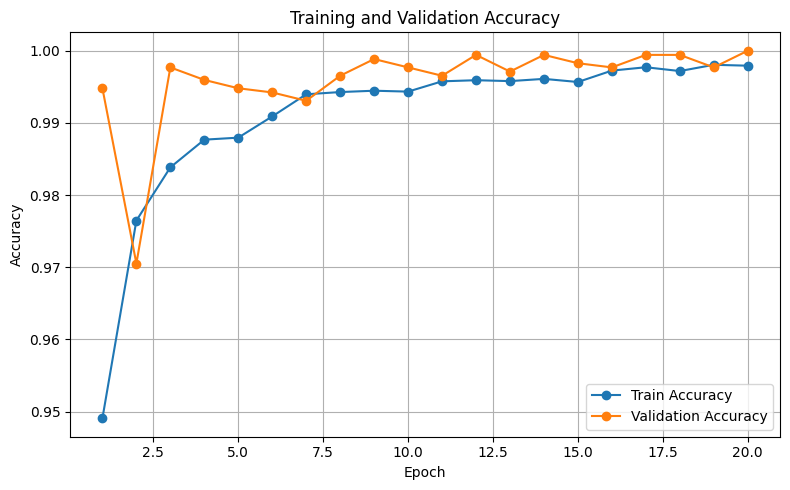

In [16]:
# =========================================
# CELL 16: Accuracy Curves
# =========================================
epochs_range = range(1, len(history["train_accuracy"]) + 1)

plt.figure(figsize=(8, 5))
plt.plot(epochs_range, history["train_accuracy"], marker="o", label="Train Accuracy")
plt.plot(epochs_range, history["val_accuracy"], marker="o", label="Validation Accuracy")
plt.title("Training and Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, "accuracy_curves.png"))
plt.show()

Test Accuracy: 0.9982668977469671

              precision    recall  f1-score   support

        male       1.00      1.00      1.00       865
      female       1.00      1.00      1.00       866

    accuracy                           1.00      1731
   macro avg       1.00      1.00      1.00      1731
weighted avg       1.00      1.00      1.00      1731

Confusion Matrix:
[[863   2]
 [  1 865]]


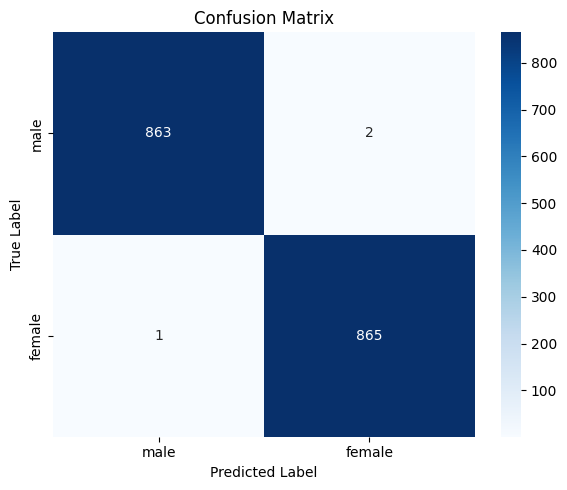

In [17]:
# =========================================
# CELL 17: Test Evaluation + Confusion Matrix
# =========================================
model.load_state_dict(torch.load(MODEL_PATH))
model.eval()

test_predictions = []
test_labels = []

with torch.no_grad():
    for mel, label in test_loader:
        mel = mel.to(device)

        output = model(mel)
        probs = torch.sigmoid(output)
        preds = (probs > 0.5).int().cpu().numpy().flatten()

        test_predictions.extend(preds)
        test_labels.extend(label.numpy())

test_accuracy = accuracy_score(test_labels, test_predictions)
cm = confusion_matrix(test_labels, test_predictions)

print("Test Accuracy:", test_accuracy)
print()
print(classification_report(test_labels, test_predictions, target_names=["male", "female"]))
print("Confusion Matrix:")
print(cm)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["male", "female"],
    yticklabels=["male", "female"]
)
plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, "confusion_matrix.png"))
plt.show()

In [18]:
# =========================================
# CELL 18: Final Paths
# =========================================
print("Processed data folder :", PROCESSED_DIR)
print("Best model path       :", MODEL_PATH)
print("Best validation acc   :", best_val_accuracy)
print("Plots folder          :", PLOTS_DIR)

Processed data folder : /kaggle/working/processed_data
Best model path       : /kaggle/working/best_gender_model.pth
Best validation acc   : 1.0
Plots folder          : /kaggle/working/plots
